# Sprint 1 — EDA: Medicamentos
## Medicamentos Vitales No Disponibles — INVIMA (2018–2026)

**Proyecto:** Entre la necesidad y la disponibilidad  
**Autores:** Julian David Medina Ceballos | Laura Catalina Mariaca Varona  
**Insumo:** `mvnd_limpio.csv`

### Objetivos del sprint
- Identificar principios activos con mayor demanda
- Analizar formas farmacéuticas y medicamentos combinados
- Caracterizar volúmenes solicitados (`CANTIDAD`)


##  Configuración


In [ ]:
%pip install pandas matplotlib seaborn scipy openpyxl --quiet
import sys

RUTA_LIMPIO = '../datasets/mvnd_limpio.csv'


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='muted')

CARPETA_GRAFICOS = '../graficos/Graficos_eda'
import os
os.makedirs(CARPETA_GRAFICOS, exist_ok=True)

def guardar(fig, nombre):
    ruta = os.path.join(CARPETA_GRAFICOS, nombre)
    fig.savefig(ruta, dpi=150, bbox_inches='tight')
    print(f' Guardado: {ruta}')


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df = pd.read_csv(RUTA_LIMPIO, encoding='utf-8-sig')
df['FECHA_AUTORIZACION'] = pd.to_datetime(df['FECHA_AUTORIZACION'])

# Corregir nombre de columna año parcial (encoding en CSV)
for c in list(df.columns):
    if 'PARCIAL' in c.upper():
        df = df.rename(columns={c: 'ANIO_PARCIAL'})

print(f' Dataset cargado: {len(df):,} registros × {df.shape[1]} columnas')
print(f'   Período: {df["FECHA_AUTORIZACION"].min().date()} → {df["FECHA_AUTORIZACION"].max().date()}')


 Dataset cargado: 9,413 registros × 21 columnas
   Período: 2018-01-09 → 2026-06-12


## 1. Concentración de la demanda por principio activo


 Guardado: ../graficos/Graficos_eda\03_top20_principios_activos.png


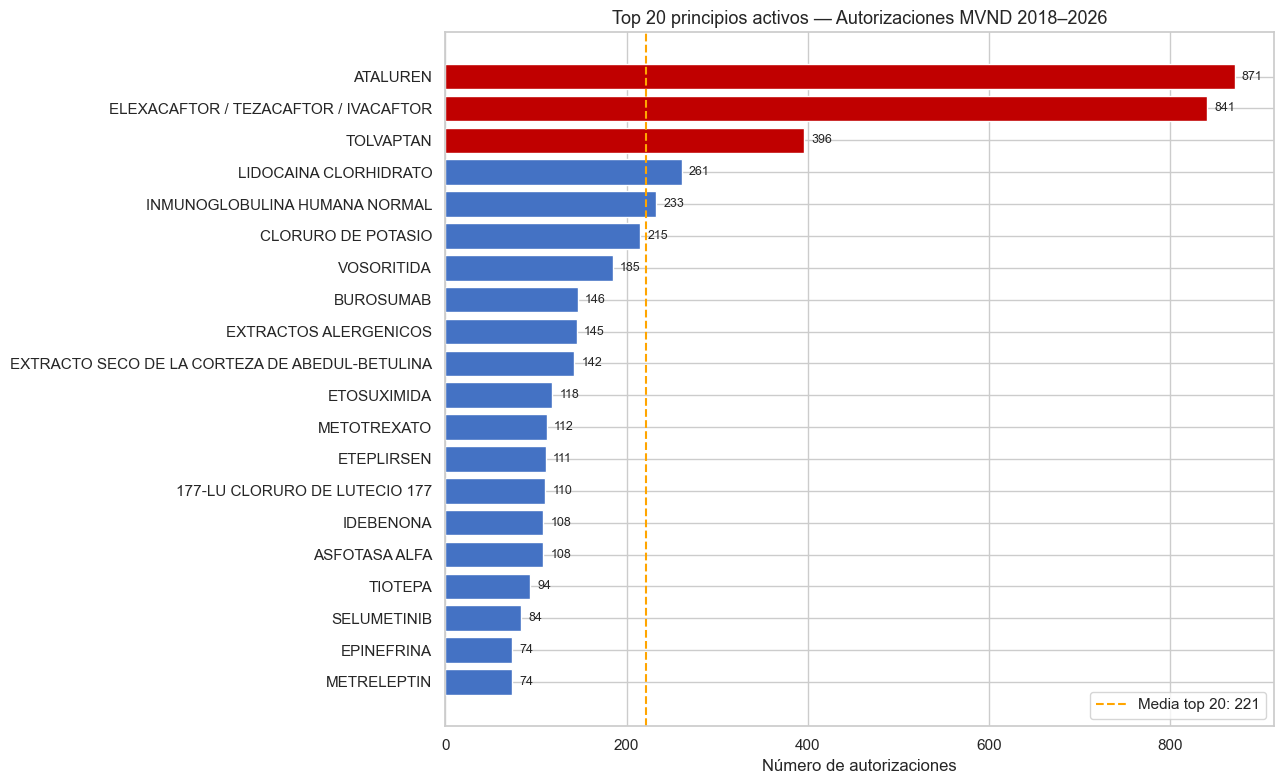

Principios activos únicos: 587
Top 3 concentran: 22.4% | Top 10: 36.5%


,Autorizaciones,count
0,ATALUREN,871
1,ELEXACAFTOR / TEZACAFTOR / IVACAFTOR,841
2,TOLVAPTAN,396
3,LIDOCAINA CLORHIDRATO,261
4,INMUNOGLOBULINA HUMANA NORMAL,233
5,CLORURO DE POTASIO,215
6,VOSORITIDA,185
7,BUROSUMAB,146
8,EXTRACTOS ALERGENICOS,145
9,EXTRACTO SECO DE LA CORTEZA DE ABEDUL-BETULINA,142


In [10]:

TOP_N = 20
top_activos = df['PRINCIPIO_ACTIVO'].value_counts().head(TOP_N)
total = len(df)
top3_pct = top_activos.head(3).sum() / total * 100
top10_pct = top_activos.head(10).sum() / total * 100

fig, ax = plt.subplots(figsize=(13, 8))
colores = ['#c00000' if i < 3 else '#4472C4' for i in range(len(top_activos))]
bars = ax.barh(top_activos.index[::-1], top_activos.values[::-1], color=colores[::-1])
for bar, val in zip(bars, top_activos.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 20 principios activos — Autorizaciones MVND 2018–2026', fontsize=13)
ax.set_xlabel('Número de autorizaciones')
ax.axvline(top_activos.mean(), color='orange', linestyle='--', label=f'Media top 20: {top_activos.mean():.0f}')
ax.legend()
plt.tight_layout()
guardar(plt.gcf(), '03_top20_principios_activos.png')
plt.show()

print(f'Principios activos únicos: {df["PRINCIPIO_ACTIVO"].nunique():,}')
print(f'Top 3 concentran: {top3_pct:.1f}% | Top 10: {top10_pct:.1f}%')
display(top_activos.reset_index().rename(columns={'index':'Principio activo', 'PRINCIPIO_ACTIVO':'Autorizaciones'}))



## 2. Curva de Pareto (concentración)


 Guardado: ../graficos/Graficos_eda\03_pareto_principios_activos.png


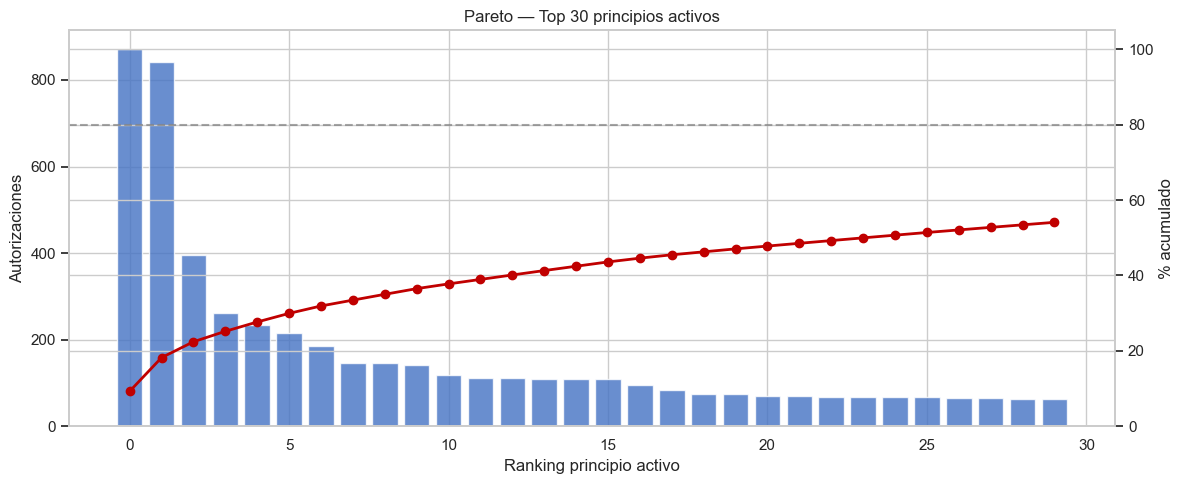

≈ 103 principios activos explican el 80% de las autorizaciones


In [11]:

vc = df['PRINCIPIO_ACTIVO'].value_counts()
cum = vc.cumsum() / vc.sum() * 100
n_80 = (cum <= 80).sum() + 1

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(min(30, len(vc))), vc.head(30).values, color='#4472C4', alpha=0.8)
ax1.set_ylabel('Autorizaciones')
ax1.set_xlabel('Ranking principio activo')
ax1.set_title('Pareto — Top 30 principios activos')

ax2 = ax1.twinx()
ax2.plot(range(min(30, len(cum))), cum.head(30).values, color='#c00000', marker='o', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)
ax2.set_ylabel('% acumulado')
ax2.set_ylim(0, 105)
plt.tight_layout()
guardar(plt.gcf(), '03_pareto_principios_activos.png')
plt.show()
print(f'≈ {n_80} principios activos explican el 80% de las autorizaciones')



## 3. Formas farmacéuticas


 Guardado: ../graficos/Graficos_eda\03_formas_farmaceuticas.png


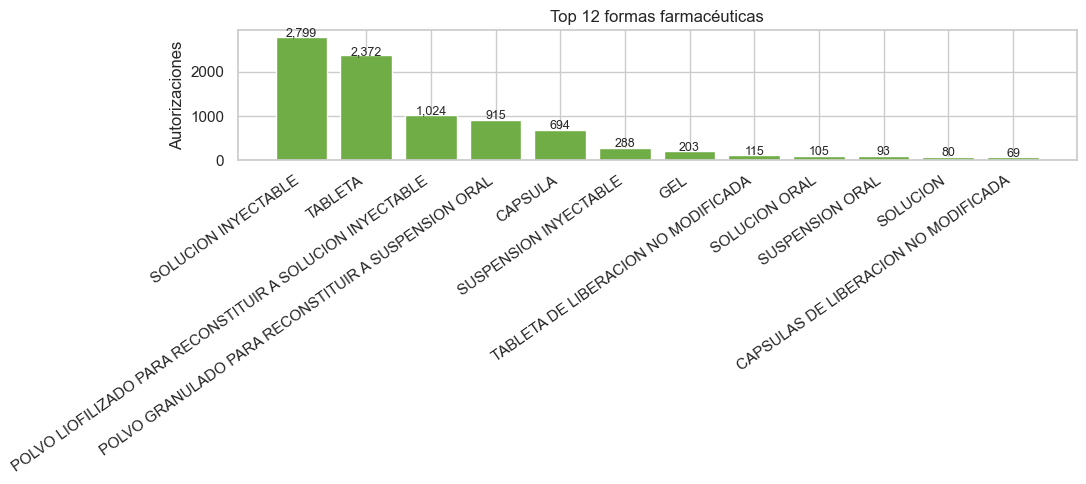

In [12]:

top_formas = df['FORMA_FARMACEUTICA'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_formas.index, top_formas.values, color='#70AD47')
for i, v in enumerate(top_formas.values):
    ax.text(i, v + 15, f'{v:,}', ha='center', fontsize=9)
ax.set_title('Top 12 formas farmacéuticas')
ax.set_ylabel('Autorizaciones')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
guardar(plt.gcf(), '03_formas_farmaceuticas.png')
plt.show()



## 4. Medicamentos combinados (`ES_COMBINADO`)


 Guardado: ../graficos/Graficos_eda\03_medicamentos_combinados.png


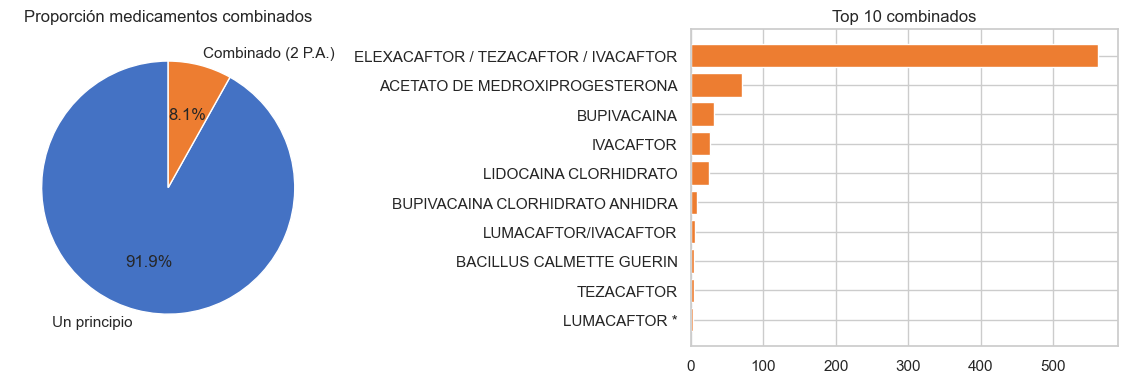

ES_COMBINADO
Simples       8649
Combinados     764
Name: count, dtype: int64


In [13]:

comb = df['ES_COMBINADO'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(comb.values, labels=['Un principio', 'Combinado (2 P.A.)'],
            autopct='%1.1f%%', colors=['#4472C4', '#ED7D31'], startangle=90)
axes[0].set_title('Proporción medicamentos combinados')
top_comb = df[df['ES_COMBINADO']==1]['PRINCIPIO_ACTIVO'].value_counts().head(10)
axes[1].barh(top_comb.index[::-1], top_comb.values[::-1], color='#ED7D31')
axes[1].set_title('Top 10 combinados')
plt.tight_layout()
guardar(plt.gcf(), '03_medicamentos_combinados.png')
plt.show()
print(comb.rename({0:'Simples', 1:'Combinados'}))



## 5. Cantidad solicitada por tipo de solicitud


 Guardado: ../graficos/Graficos_eda\03_cantidad_por_tipo.png


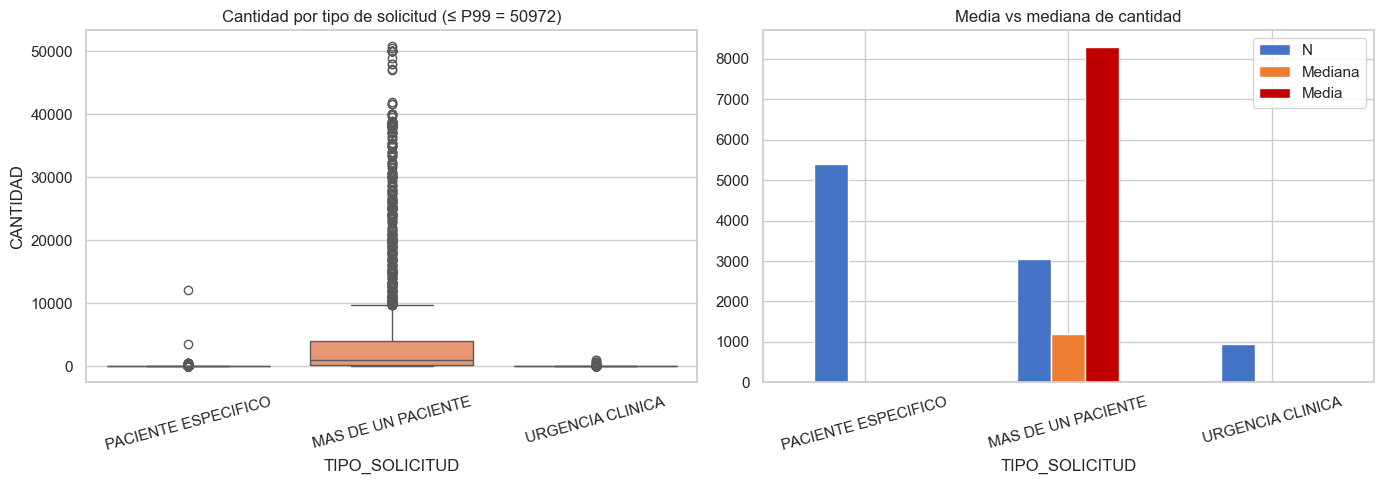

                     count  median    mean
TIPO_SOLICITUD                            
PACIENTE ESPECIFICO   5408     9.0    24.5
MAS DE UN PACIENTE    3061  1200.0  8291.9
URGENCIA CLINICA       944    12.0    32.8


In [14]:

p99 = df['CANTIDAD'].quantile(0.99)
df_c = df[df['CANTIDAD'] <= p99].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = ['PACIENTE ESPECIFICO', 'MAS DE UN PACIENTE', 'URGENCIA CLINICA']
sns.boxplot(data=df_c, x='TIPO_SOLICITUD', y='CANTIDAD', order=orden, ax=axes[0], palette='Set2')
axes[0].set_title(f'Cantidad por tipo de solicitud (≤ P99 = {p99:.0f})')
axes[0].tick_params(axis='x', rotation=15)

stats = df.groupby('TIPO_SOLICITUD')['CANTIDAD'].agg(['count','median','mean']).reindex(orden)
stats.plot(kind='bar', ax=axes[1], color=['#4472C4','#ED7D31','#c00000'])
axes[1].set_title('Media vs mediana de cantidad')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['N','Mediana','Media'])
plt.tight_layout()
guardar(plt.gcf(), '03_cantidad_por_tipo.png')
plt.show()
print(stats.round(1))



## 6. Categorías de cantidad


 Guardado: ../graficos/Graficos_eda\03_cantidad_categoria.png


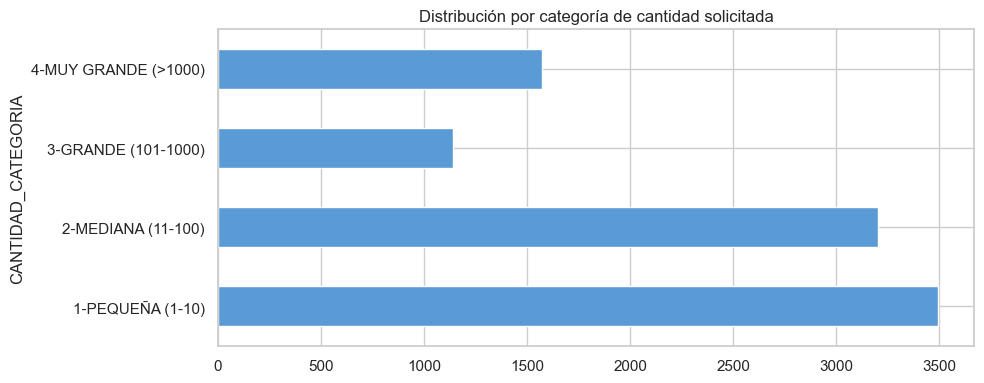

In [15]:

cat = df['CANTIDAD_CATEGORIA'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
cat.plot(kind='barh', ax=ax, color='#5B9BD5')
ax.set_title('Distribución por categoría de cantidad solicitada')
plt.tight_layout()
guardar(plt.gcf(), '03_cantidad_categoria.png')
plt.show()



## Hallazgos — Sprint 1 (Medicamentos)

| Hallazgo | Evidencia |
|----------|-----------|
| Alta concentración | Top 3 principios activos (fibrosis quística, distrofia muscular, Bardet-Biedl) dominan la demanda |
| Cola larga | Cientos de principios activos con pocas autorizaciones cada uno |
| Formas | Soluciones, tabletas y polvos liofilizados son las más frecuentes |
| Combinados | ~8% de registros corresponden a 2 principios activos |
| Cantidad | Distribución muy sesgada; urgencias y solicitudes masivas elevan la media |

**Siguiente:** `04_EDA_Diagnosticos.ipynb`
